In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Import our custom package
from cooltrack.constants import INDEPENDENT_DIMS
from cooltrack.data_loader import load_grid

# Set publication-quality plotting style
sns.set_theme(style="whitegrid", context="talk")

# Data Path
GRID_FILE_PATH = "../data/HADES_grid/hades_processed_grid.parquet"
GRID_FILE_PATH = "../../exoweave/outputs/master_grid_data.h5"

In [2]:
print("Loading raw grid data...")
df_raw = load_grid(GRID_FILE_PATH)
print(f"Loaded {len(df_raw):,} rows.")

2026-03-05 14:34:57,829 - INFO - Loading Exoweave HDF5 file: ../../exoweave/outputs/master_grid_data.h5...


Loading raw grid data...


2026-03-05 14:34:58,813 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (109, 43)


Loaded 109 rows.


In [3]:
print("Flagging numerical outliers in the grid...")
# Define features and target
dsdt_features = INDEPENDENT_DIMS + ['S_physical', 'T_int']
X_temp = df_raw[dsdt_features]
y_temp = df_raw['abs_log_dsdt']

# Train a fast baseline model
temp_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
temp_model.fit(X_temp, y_temp)

# Find errors > 1.0 dex (factor of 10 off from surrounding physics)
all_preds = temp_model.predict(X_temp)
errors_dex = np.abs(y_temp - all_preds)
df_raw['is_outlier'] = errors_dex > 1.0

df_clean = df_raw[~df_raw['is_outlier']].copy()
df_outliers = df_raw[df_raw['is_outlier']].copy()

print(f"Found {len(df_outliers):,} outliers and {len(df_clean):,} clean points.")

Flagging numerical outliers in the grid...
Found 0 outliers and 109 clean points.


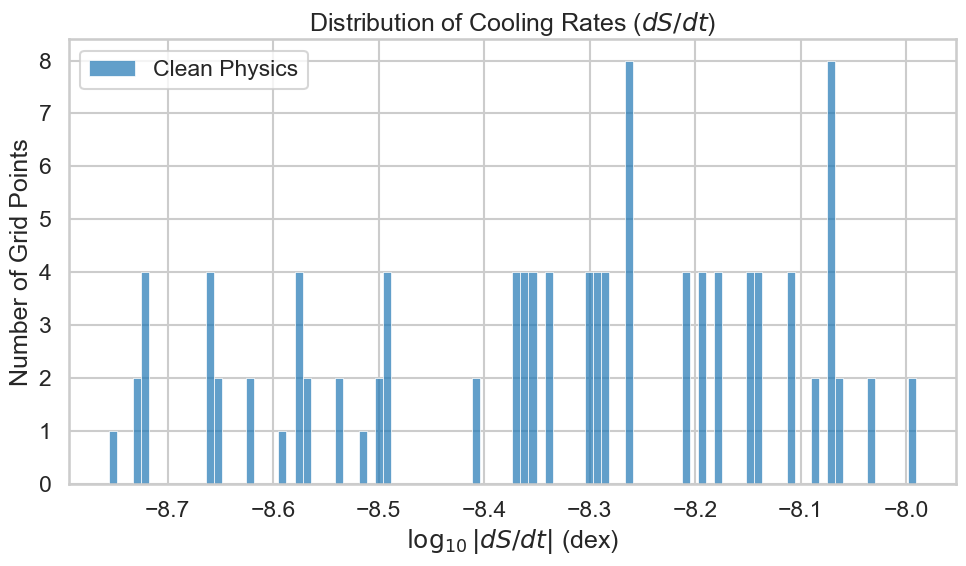

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df_clean['abs_log_dsdt'], bins=100, color='tab:blue', label='Clean Physics', alpha=0.7, ax=ax)
sns.histplot(df_outliers['abs_log_dsdt'], bins=50, color='tab:red', label='Numerical Noise', alpha=1.0, ax=ax)

ax.set_title("Distribution of Cooling Rates ($dS/dt$)")
ax.set_xlabel("$\log_{10}|dS/dt|$ (dex)")
ax.set_ylabel("Number of Grid Points")
ax.legend()
plt.tight_layout()
plt.show()

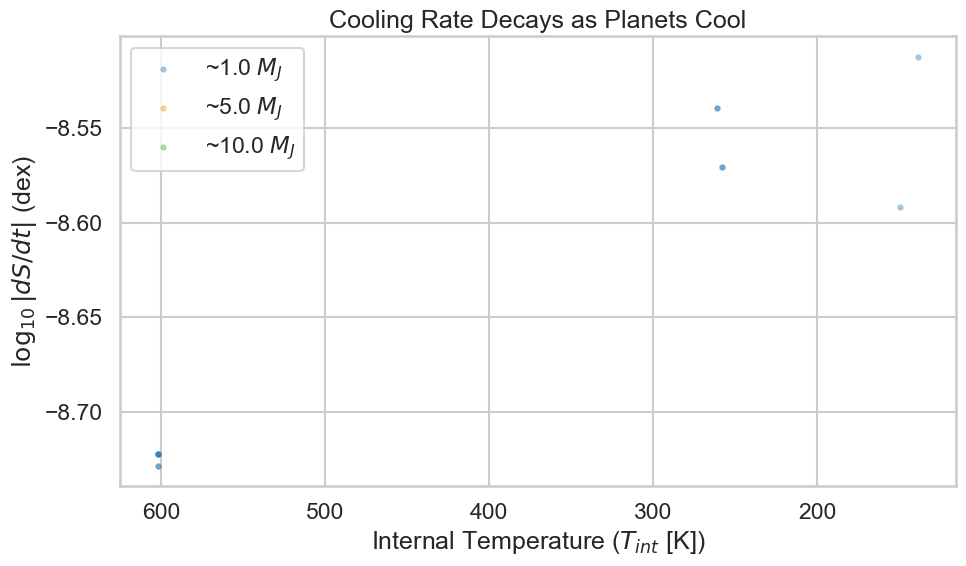

In [5]:
# Pick a few distinct masses to plot (e.g., 1, 5, and 10 Jupiter masses)
target_masses = [1.0, 5.0, 10.0, 13.0]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for mass, color in zip(target_masses, colors):
    # Slice planets close to the target mass
    slice_df = df_clean[np.isclose(df_clean['mass_Mj'], mass, atol=0.2)]
    
    # Scatter plot of T_int vs cooling rate
    ax.scatter(slice_df['T_int'], slice_df['abs_log_dsdt'], 
               alpha=0.3, s=10, color=color, label=f'~{mass} $M_J$')

ax.set_title("Cooling Rate Decays as Planets Cool")
ax.set_xlabel("Internal Temperature ($T_{int}$ [K])")
ax.set_ylabel("$\log_{10}|dS/dt|$ (dex)")
# Invert X axis because planets cool from right (hot) to left (cold)
ax.invert_xaxis() 
ax.legend()
plt.tight_layout()
plt.show()

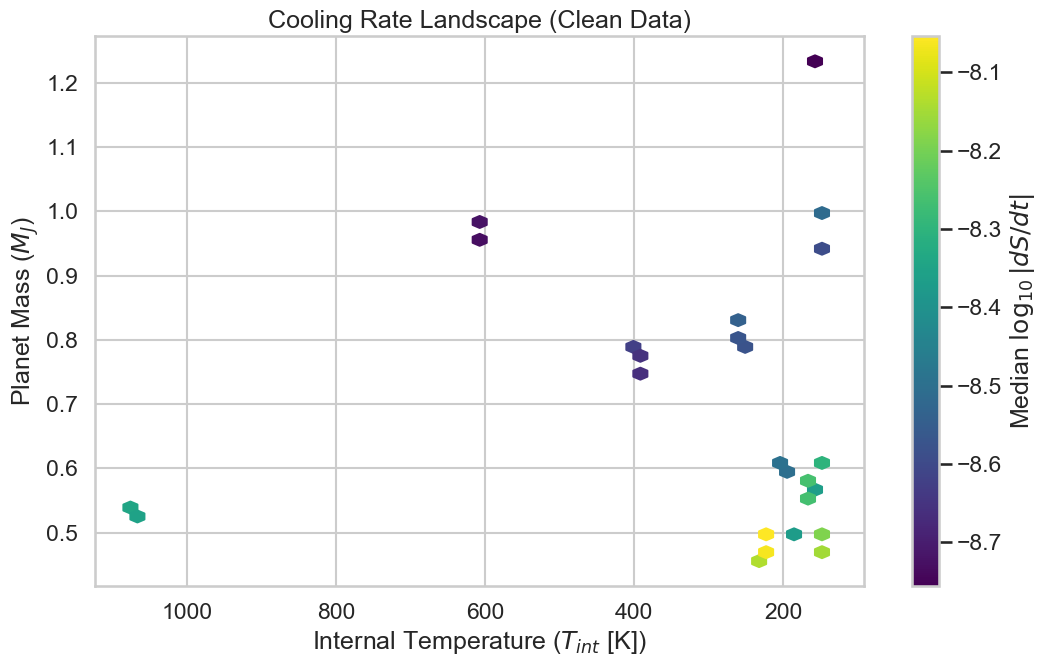

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))

# Create a hexbin plot map of the cooling rate
hb = ax.hexbin(df_clean['T_int'], df_clean['mass_Mj'], C=df_clean['abs_log_dsdt'], 
               gridsize=50, cmap='viridis', reduce_C_function=np.median)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Median $\log_{10}|dS/dt|$")

ax.set_title("Cooling Rate Landscape (Clean Data)")
ax.set_xlabel("Internal Temperature ($T_{int}$ [K])")
ax.set_ylabel("Planet Mass ($M_J$)")
ax.invert_xaxis()

plt.tight_layout()
plt.show()

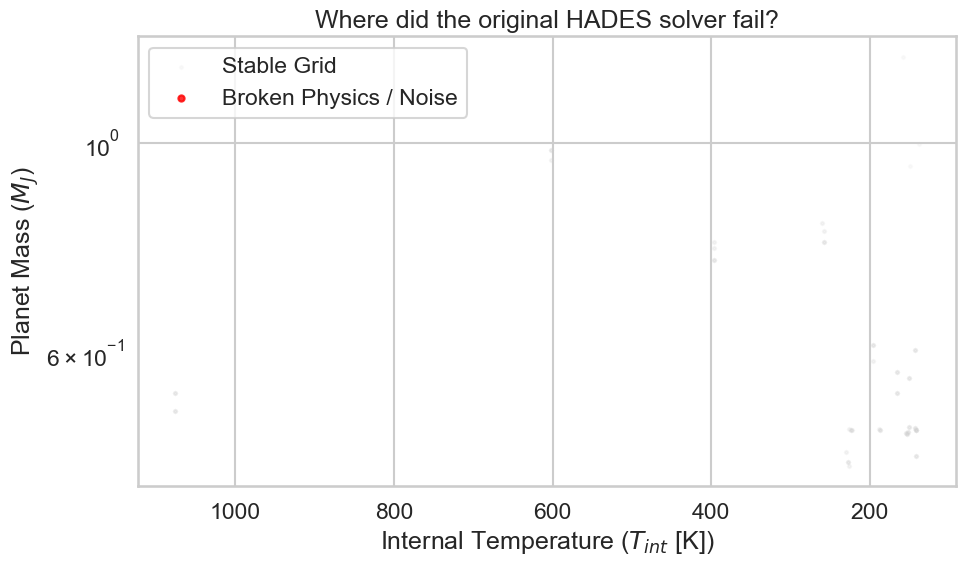

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the clean data lightly in the background
ax.scatter(df_clean['T_int'], df_clean['mass_Mj'], color='lightgray', s=5, alpha=0.1, label='Stable Grid')

# Overlay the broken points in bright red
ax.scatter(df_outliers['T_int'], df_outliers['mass_Mj'], color='red', s=20, alpha=0.8, label='Broken Physics / Noise')

ax.set_title("Where did the original HADES solver fail?")
ax.set_xlabel("Internal Temperature ($T_{int}$ [K])")
ax.set_ylabel("Planet Mass ($M_J$)")
ax.set_yscale('log')
ax.invert_xaxis()
ax.legend()

plt.tight_layout()
plt.show()

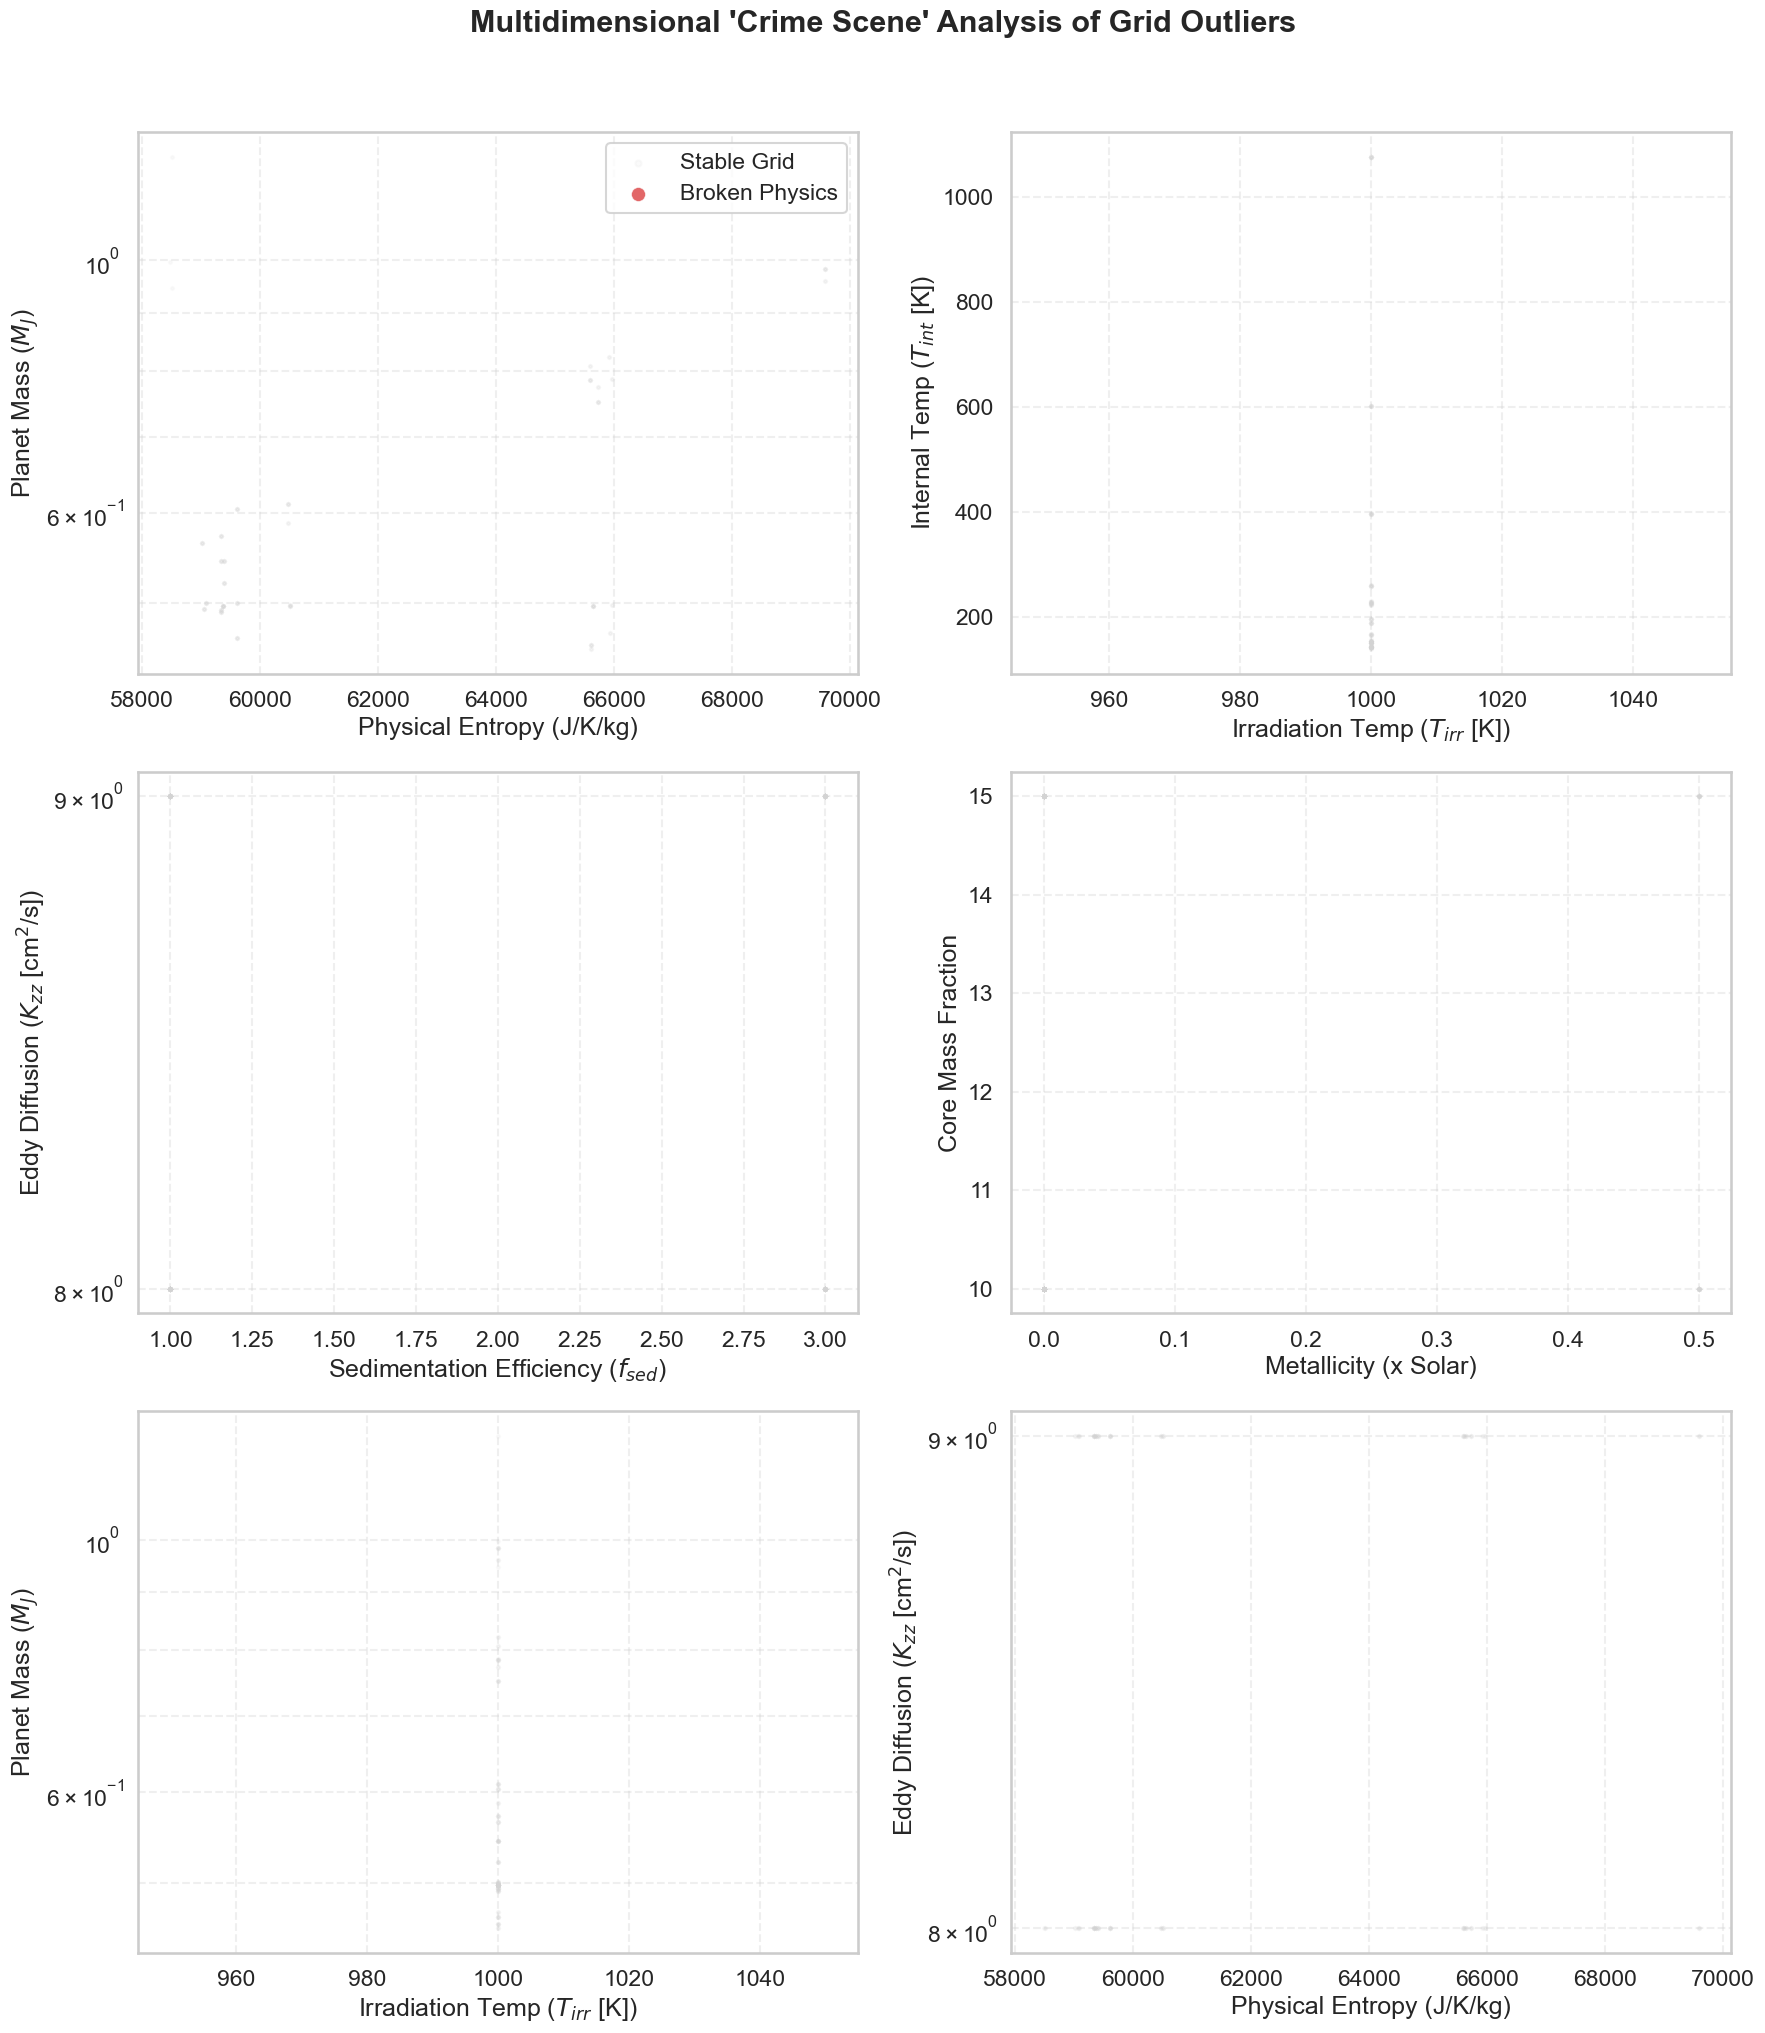

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

# Configuration for each plot: 
# (X-axis, Y-axis, X-label, Y-label, X-log, Y-log, Invert-X)
plot_configs = [
    # 1. Mass vs Entropy (The fundamental evolutionary state)
    ('S_physical', 'mass_Mj', 'Physical Entropy (J/K/kg)', 'Planet Mass ($M_J$)', False, True, False),
    
    # 2. T_int vs T_irr (The radiative-convective boundary check)
    ('T_irr', 'T_int', 'Irradiation Temp ($T_{irr}$ [K])', 'Internal Temp ($T_{int}$ [K])', False, False, False),
    
    # 3. Kzz vs F_sed (Atmospheric stability and cloud mixing)
    ('f_sed', 'kzz', 'Sedimentation Efficiency ($f_{sed}$)', 'Eddy Diffusion ($K_{zz}$ [cm$^2$/s])', False, True, False),
    
    # 4. Metallicity vs Core Mass (Equation of State stress test)
    ('Met', 'core', 'Metallicity (x Solar)', 'Core Mass Fraction', False, False, False),
    
    # 5. Mass vs T_irr (Does irradiation break low-mass planets?)
    ('T_irr', 'mass_Mj', 'Irradiation Temp ($T_{irr}$ [K])', 'Planet Mass ($M_J$)', False, True, False),
    
    # 6. Entropy vs Kzz (Deep interior vs upper atmosphere mixing)
    ('S_physical', 'kzz', 'Physical Entropy (J/K/kg)', 'Eddy Diffusion ($K_{zz}$ [cm$^2$/s])', False, True, False)
]

for i, (ax, (x_col, y_col, x_label, y_label, x_log, y_log, inv_x)) in enumerate(zip(axes, plot_configs)):
    
    # Check if the columns actually exist in our dataset before plotting
    if x_col in df_raw.columns and y_col in df_raw.columns:
        # Background: The stable grid points
        ax.scatter(df_clean[x_col], df_clean[y_col], 
                   color='lightgray', s=5, alpha=0.1, label='Stable Grid')
        
        # Foreground: The numerical outliers
        ax.scatter(df_outliers[x_col], df_outliers[y_col], 
                   color='tab:red', s=25, alpha=0.7, edgecolor='white', linewidth=0.5, label='Broken Physics')

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)

        if x_log: ax.set_xscale('log')
        if y_log: ax.set_yscale('log')
        if inv_x: ax.invert_xaxis()

        # Add a grid to help read log scales
        ax.grid(True, which="both", ls="--", alpha=0.3)

        # Only put the legend on the first plot to keep it clean
        if i == 0:
            ax.legend(markerscale=2)
    else:
        ax.text(0.5, 0.5, f"Missing columns:\n{x_col} or {y_col}", 
                ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Multidimensional 'Crime Scene' Analysis of Grid Outliers", fontsize=22, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()